<a href="https://colab.research.google.com/github/Aqillaaprly/PVCK_2025/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import glob
import math

# Transformasi Linier Brightness

Mengubah tingkat kecerahan citra
Masukkan nilai kecerahan50


/tmp/ipython-input-1838627233.py:15: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


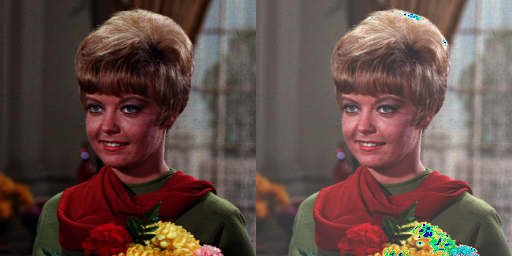

In [3]:
print('Mengubah tingkat kecerahan citra')
print('================================')

try:
  brightness = int(input('Masukkan nilai kecerahan'))
except ValueError:
  print('Nilai harus berupa angka')

original = cv.imread ('/content/drive/MyDrive/Images/female.tiff')
brightness_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

# D1 PRACTICAL ASSIGMENT

1.   Implement image inversion on Google Collaboratory using the formulas found in the Theory Review section, resulting in the following output:

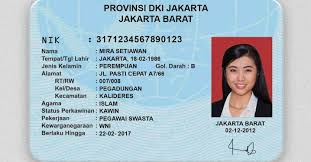

In [4]:
imgktp = cv.imread('/content/drive/MyDrive/PCVK/IMAGE/ktipi.jpg')
cv2_imshow(imgktp)

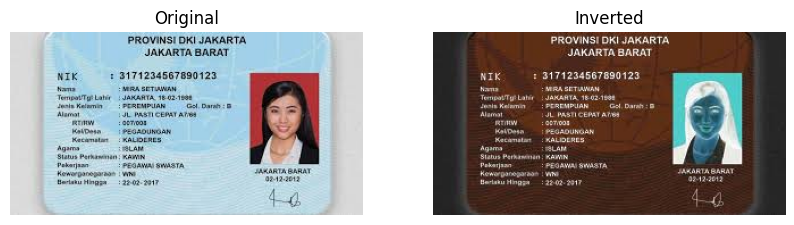

In [5]:
imgrgb = cv.cvtColor(imgktp, cv.COLOR_BGR2RGB)
inverted_img = 255 - imgrgb

# Tampilkan hasil
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imgrgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(inverted_img)
plt.title("Inverted")
plt.axis("off")

plt.show()

2. Implement the contrast transformation in Google Collaboratory using the formula found in the Theory Review section for contrast, resulting in the following output:

 Mengubah kontras dan tingkat kecerahan citra 
----------------------------------
Masukkan tingkat kecerahan [-255 - 255]: 50
Masukkan nilai kontras [1.0 - 3.0]: 2


/tmp/ipython-input-2001986694.py:16: RuntimeWarning: overflow encountered in scalar add
  temp = original[y,x,c] + beta


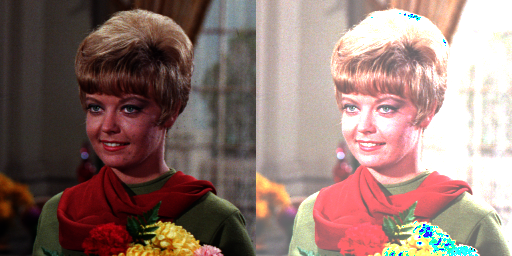

In [6]:
print(' Mengubah kontras dan tingkat kecerahan citra ')
print('----------------------------------')
try:
    beta = int(input('Masukkan tingkat kecerahan [-255 - 255]: '))
    alpha = float(input('Masukkan nilai kontras [1.0 - 3.0]: '))
except ValueError:
    print('Error, input tidak valid')

original = cv.imread('/content/drive/MyDrive/Images/female.tiff')
result = np.zeros(original.shape, original.dtype)


for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            temp = original[y,x,c] + beta
            result[y,x,c] = np.clip(alpha * temp, 0, 255)

final_frame = cv.hconcat((original, result))
cv2_imshow(final_frame)

3. Implement the logarithmic brightness transformation in Google Collaboratory using the formula found in the Theory Review section for log transformation, resulting in the following output:

 Logarithmic Brightness Transformation 
----------------------------------
Masukkan nilai konstanta kecerahan (contoh 20): 40


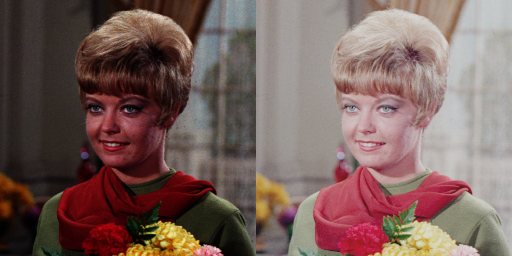

In [7]:
print(" Logarithmic Brightness Transformation ")
print("----------------------------------")

try:
    c = float(input("Masukkan nilai konstanta kecerahan (contoh 20): "))
except ValueError:
    print("Error, input tidak valid")
    c = 1.0
original = cv.imread('/content/drive/MyDrive/Images/female.tiff')

# Konversi ke float
log_img = (c * np.log(1 + original.astype(np.float32))).astype(np.uint8)

final = cv.hconcat([original, log_img])
cv2_imshow(final)


4. Implement the grayscale transformation using the averaging, lightness, and luminance methods on Google Collaboratory using the formulas found in the Theory Review section, resulting in the following output:

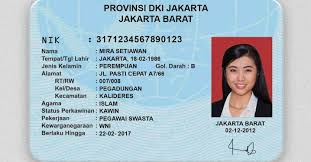

In [8]:
imgktp = cv.imread('/content/drive/MyDrive/PCVK/IMAGE/ktipi.jpg')
cv2_imshow(imgktp)

**Averaging**

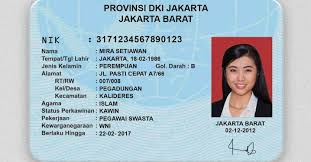

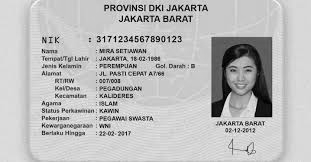

In [9]:
gray_avg = np.mean(imgktp, axis=2).astype(np.uint8)

# Show original and grayscale image
cv2_imshow(imgktp)
cv2_imshow(gray_avg)


**Lightness**

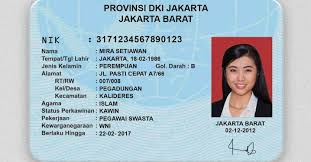

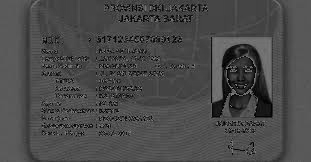

In [11]:
min_val = np.min(imgktp, axis=2)
max_val = np.max(imgktp, axis=2)
gray_lightness = ((min_val + max_val) / 2).astype(np.uint8)

cv2_imshow(imgktp)
cv2_imshow(gray_lightness)

**Luminance**

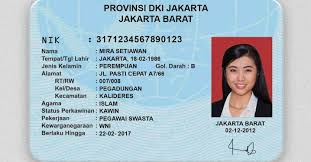

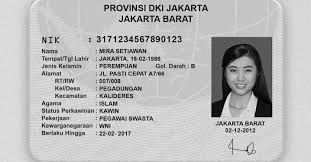

In [14]:
gray_luminance = (0.299 * imgktp[:, :, 2] + 0.587 * imgktp[:, :, 1] + 0.114 * imgktp[:, :, 0]).astype(np.uint8)

cv2_imshow(imgktp)
cv2_imshow(gray_luminance)

5. Display certain colors in an image and convert other colors to grayscale. For example, display blue in the input image and convert other non-blue parts to grayscale,as in the following example:


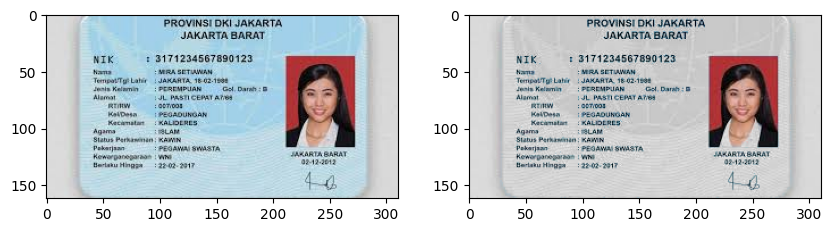

In [33]:
original = cv.imread('/content/drive/MyDrive/PCVK/IMAGE/ktipi.jpg')
selective_blue = np.zeros(original.shape, original.dtype)

for x in range(original.shape[0]):
  for y in range(original.shape[1]):
    b = int(original[x, y, 0])
    g = int(original[x, y, 1])
    r = int(original[x, y, 2])

    average_grayscale = (r+g+b)/3
    if(r < 250 and g > 0 and b > 200):
      selective_blue[x, y] = average_grayscale
    else:
      selective_blue[x, y] = original[x, y]

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
color_gray_rgb = cv.cvtColor(selective_blue, cv.COLOR_BGR2RGB)
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.imshow(original_rgb)
plt.axis()
plt.subplot(1,2,2)
plt.imshow(color_gray_rgb)
plt.axis()
plt.show()

# D2 ARITHMETIC AND LOGICAL OPERATION

1. Make Gamma Correction according to the following instructions

 Gamma Correction pada citra 
-----------------------------
Masukkan nilai Gamma: 3


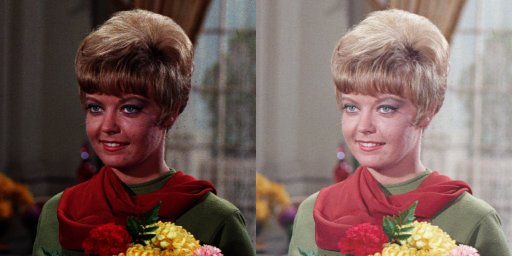

In [34]:
print(' Gamma Correction pada citra ')
print('-----------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

fem = cv.imread('/content/drive/MyDrive/Images/female.tiff')

gamma_corrected = np.array(255 * ((fem / 255) ** (1.0/gamma)), dtype='uint8')

final_frame_gamma = cv.hconcat([fem, gamma_corrected])
cv2_imshow(final_frame_gamma)

2. Create Image Depth Simulation

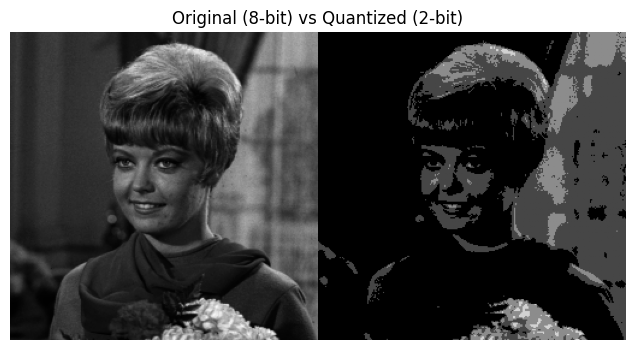

In [35]:
bit_depth = 2
original = cv.imread('/content/drive/MyDrive/Images/female.tiff',cv.IMREAD_GRAYSCALE)
levels = 2 ** bit_depth
step = 256 // levels

quantized = (original // step) * step
quantized = np.uint8(quantized)

final_image = cv.hconcat([original, quantized])

plt.figure(figsize=(8,4))
plt.imshow(final_image, cmap='gray')
plt.axis("off")
plt.title(f"Original (8-bit) vs Quantized ({bit_depth}-bit)")
plt.show()

3. Create an Average Denoising module

Total noisy images loaded: 100


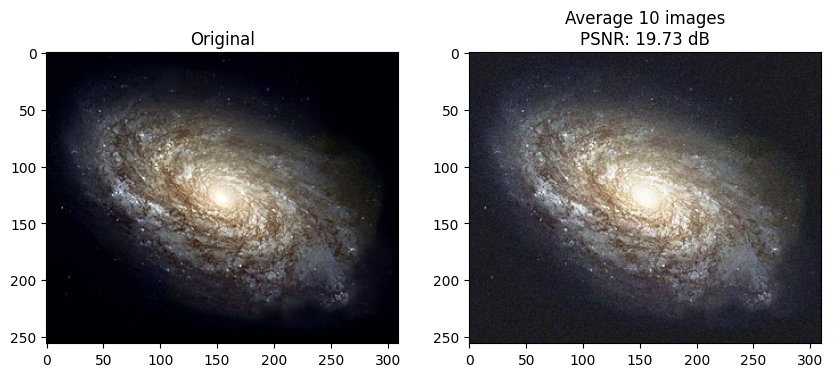

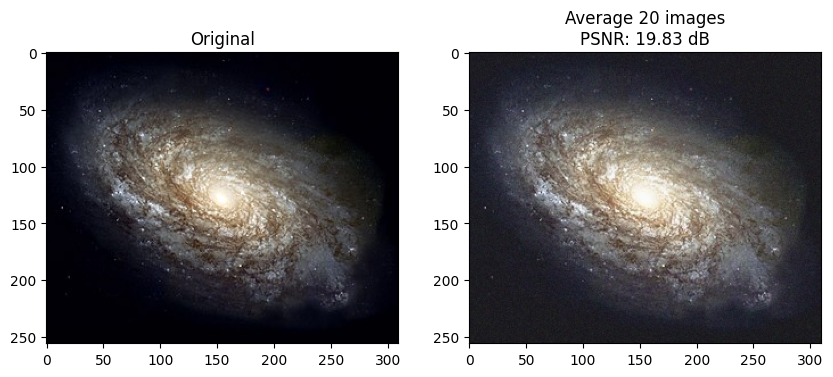

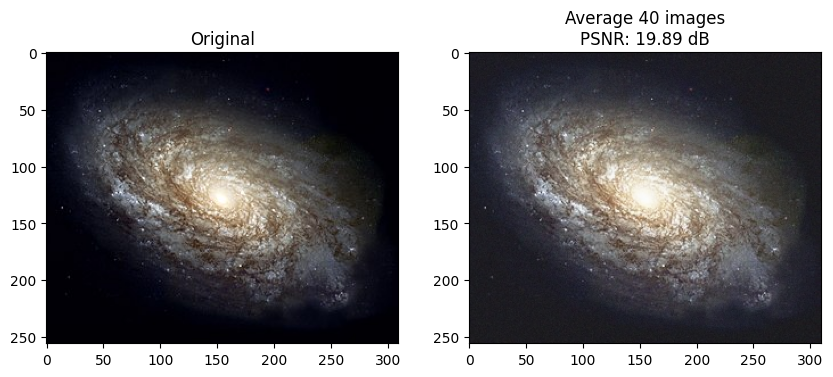

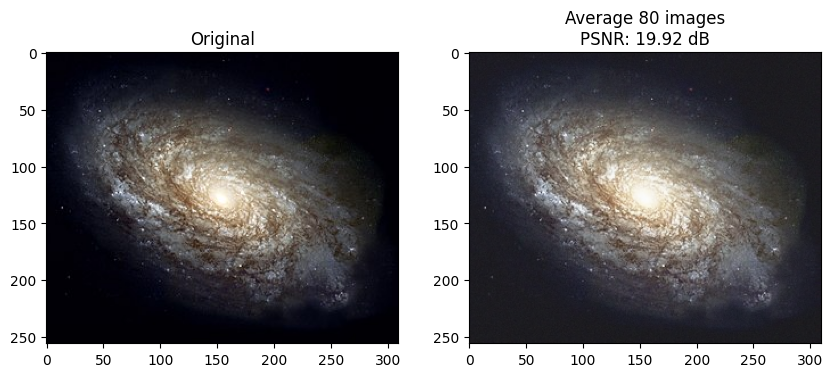

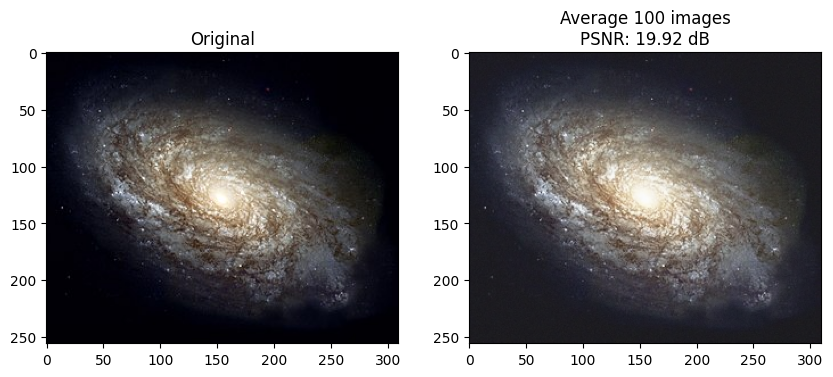

No | Number of Images | PSNR (dB)
----------------------------------
1. | 10                | 19.73
2. | 20                | 19.83
3. | 40                | 19.89
4. | 80                | 19.92
5. | 100               | 19.92


In [38]:
original = cv.imread('/content/drive/MyDrive/Images/galaxy.jpg')
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)

cv_img = []
for img in glob.glob('/content/drive/MyDrive/Images/noises/*.jpg'):
    n = cv.imread(img)
    n = cv.cvtColor(n, cv.COLOR_BGR2RGB)
    cv_img.append(n)

print(f"Total noisy images loaded: {len(cv_img)}")

def psnr(target, ref):
    mse = np.mean((target.astype(np.float32) - ref.astype(np.float32)) ** 2)
    if mse == 0:
        return 100
    PIXEL_MAX = 255.0
    psnr = 20 * math.log10(PIXEL_MAX / math.sqrt(mse))
    return psnr

N_values = [10, 20, 40, 80, 100]
results = []

for N in N_values:
    avg_img = np.zeros_like(original, dtype=np.float32)

    for i in range(N):
        avg_img += cv_img[i].astype(np.float32)

    avg_img /= N
    avg_img = np.uint8(avg_img)

    psnr_value = psnr(original, avg_img)
    results.append((N, avg_img, psnr_value))

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1), plt.imshow(original), plt.title('Original')
    plt.subplot(1,2,2), plt.imshow(avg_img), plt.title(f'Average {N} images\nPSNR: {psnr_value:.2f} dB')
    plt.show()

print("No | Number of Images | PSNR (dB)")
print("----------------------------------")
for i, (N, _, psnr_val) in enumerate(results, start=1):
    print(f"{i}. | {N:<17} | {psnr_val:.2f}")

4. Create image masking

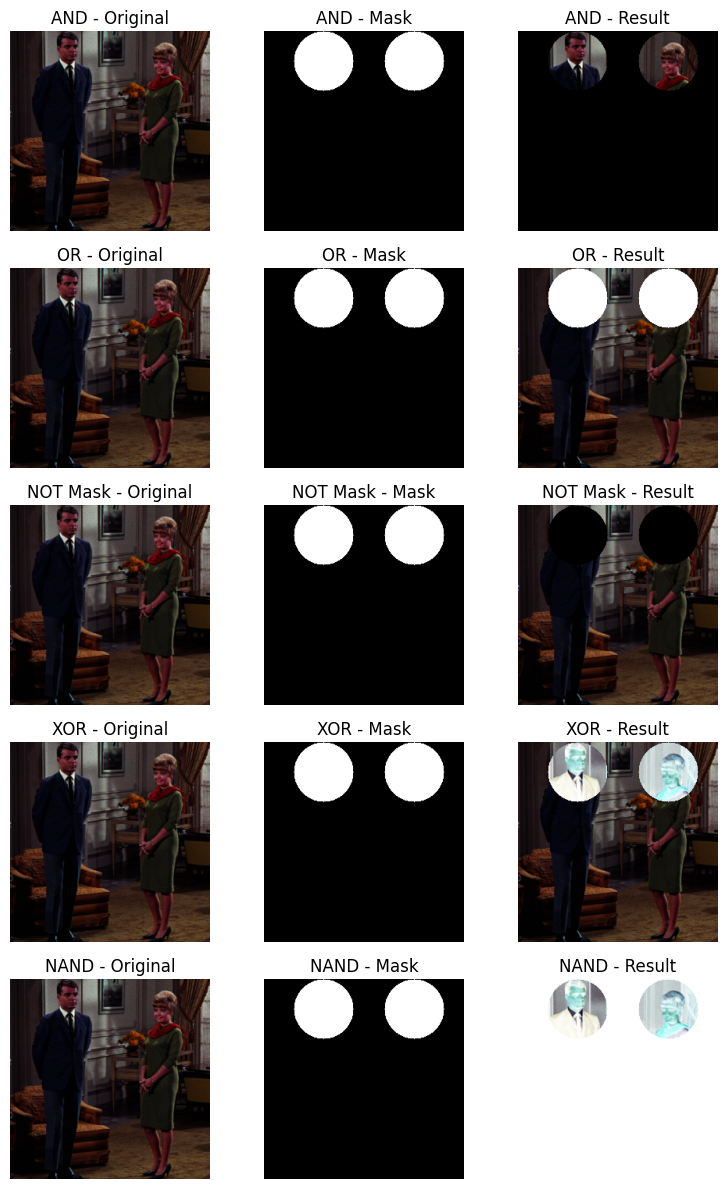

In [43]:
original = cv.imread('/content/drive/MyDrive/Images/couple.tiff')
height, width = original.shape[:2]


# Create a circular mask
mask = np.zeros((height, width), dtype=np.uint8)

# Define circle parameters
circle1_center = (int(width * 0.3), int(height * 0.15))
circle2_center = (int(width * 0.75), int(height * 0.15))
radius = int(min(height, width) * 0.15)

# Draw white filled circles
cv.circle(mask, circle1_center, radius, 255, -1)
cv.circle(mask, circle2_center, radius, 255, -1)

# Apply different operators
mask_color = cv.merge([mask, mask, mask])  # mask 3-channel

# 1. AND
and_img = cv.bitwise_and(original, original, mask=mask)

# 2. OR
or_img = cv.bitwise_or(original, mask_color)

# 3. NOT
not_mask = cv.bitwise_not(mask)
not_masked_img = cv.bitwise_and(original, original, mask=not_mask)

# 4. XOR
xor_img = cv.bitwise_xor(original, mask_color)

# 5. NAND
nand_img = cv.bitwise_not(and_img)

# Display results (Original - Mask - Result)
operators = {
    "AND": and_img,
    "OR": or_img,
    "NOT Mask": not_masked_img,
    "XOR": xor_img,
    "NAND": nand_img
}

plt.figure(figsize=(8, 12))

for idx, (op_name, result) in enumerate(operators.items()):
    # Original
    plt.subplot(len(operators), 3, idx*3 + 1)
    plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
    plt.title(f"{op_name} - Original")
    plt.axis('off')

    # Mask
    plt.subplot(len(operators), 3, idx*3 + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"{op_name} - Mask")
    plt.axis('off')

    # Result
    plt.subplot(len(operators), 3, idx*3 + 3)
    plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    plt.title(f"{op_name} - Result")
    plt.axis('off')

plt.tight_layout()
plt.show()